In [1]:
#Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#Step 2: Upload the dataset
from google.colab import files

uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


In [4]:
#Load the dataset
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
#Understand the dataset
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Dataset Shape: (7043, 21)

Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   ob

In [6]:
#Check basic statistics
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
#Check missing values
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [8]:
#Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

print(df["TotalCharges"].isnull().sum())

11


In [9]:
#Check and remove duplicates
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [10]:
#Check unique values
categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    print("\n", column)
    print(df[column].unique())


 customerID
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']

 gender
['Female' 'Male']

 Partner
['Yes' 'No']

 Dependents
['No' 'Yes']

 PhoneService
['No' 'Yes']

 MultipleLines
['No phone service' 'No' 'Yes']

 InternetService
['DSL' 'Fiber optic' 'No']

 OnlineSecurity
['No' 'Yes' 'No internet service']

 OnlineBackup
['Yes' 'No' 'No internet service']

 DeviceProtection
['No' 'Yes' 'No internet service']

 TechSupport
['No' 'Yes' 'No internet service']

 StreamingTV
['No' 'Yes' 'No internet service']

 StreamingMovies
['No' 'Yes' 'No internet service']

 Contract
['Month-to-month' 'One year' 'Two year']

 PaperlessBilling
['Yes' 'No']

 PaymentMethod
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

 Churn
['No' 'Yes']


In [11]:
#Convert SeniorCitizen to readable values
df["SeniorCitizen"] = df["SeniorCitizen"].map({
    0: "No",
    1: "Yes"
})

df["SeniorCitizen"].value_counts()

,count
SeniorCitizen,
No,5901
Yes,1142


In [12]:
#Create tenure groups

#This makes customer retention analysis easier.

def tenure_group(tenure):
    if tenure <= 12:
        return "0-1 Year"
    elif tenure <= 24:
        return "1-2 Years"
    elif tenure <= 48:
        return "2-4 Years"
    else:
        return "4+ Years"

df["TenureGroup"] = df["tenure"].apply(tenure_group)

df["TenureGroup"].value_counts()

,count
TenureGroup,
4+ Years,2239
0-1 Year,2186
2-4 Years,1594
1-2 Years,1024


In [13]:
#Total customers
total_customers = df["customerID"].nunique()

print("Total Customers:", total_customers)

Total Customers: 7043


In [14]:
#Churned customers
churned_customers = df[df["Churn"] == "Yes"]["customerID"].nunique()

print("Churned Customers:", churned_customers)

Churned Customers: 1869


In [15]:
#Retained customers
retained_customers = df[df["Churn"] == "No"]["customerID"].nunique()

print("Retained Customers:", retained_customers)

Retained Customers: 5174


In [16]:
#Churn rate
churn_rate = (
    churned_customers / total_customers
) * 100

print("Churn Rate:", round(churn_rate, 2), "%")

Churn Rate: 26.54 %


In [17]:
#Retention rate
retention_rate = (
    retained_customers / total_customers
) * 100

print("Retention Rate:", round(retention_rate, 2), "%")

Retention Rate: 73.46 %


In [19]:
#Average monthly charges
average_monthly_charges = df["MonthlyCharges"].mean()

print(
    "Average Monthly Charges:",
    round(average_monthly_charges, 2)
)

Average Monthly Charges: 64.76


In [20]:
#eda
#Churn distribution
churn_counts = df["Churn"].value_counts()

print(churn_counts)

Churn
No     5174
Yes    1869
Name: count, dtype: int64


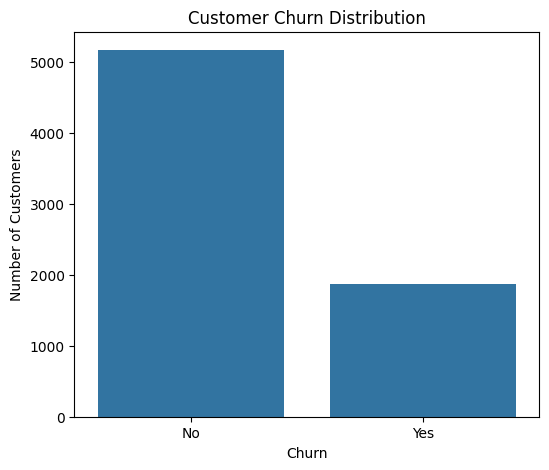

In [21]:
plt.figure(figsize=(6, 5))

sns.countplot(
    data=df,
    x="Churn"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

In [27]:
#Churn by contract type
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"]
)

print(contract_churn)

Churn             No   Yes
Contract                  
Month-to-month  2220  1655
One year        1307   166
Two year        1647    48


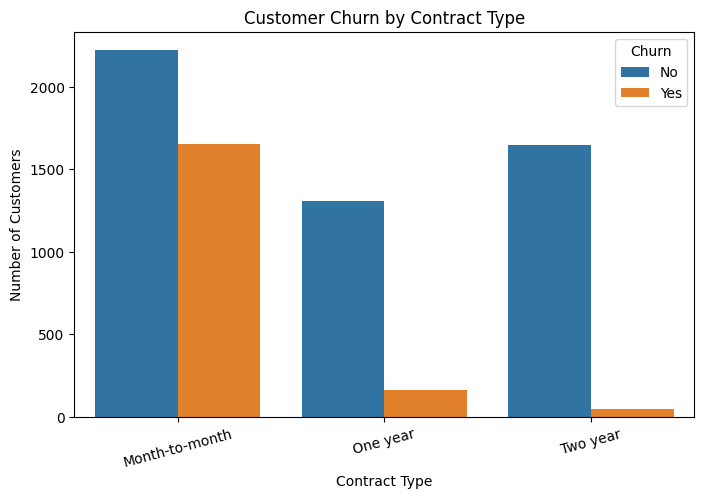

In [23]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=15)
plt.show()

In [28]:
#Churn rate by contract type
contract_churn_rate = (
    df.groupby("Contract")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

print(contract_churn_rate)

Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn, dtype: float64


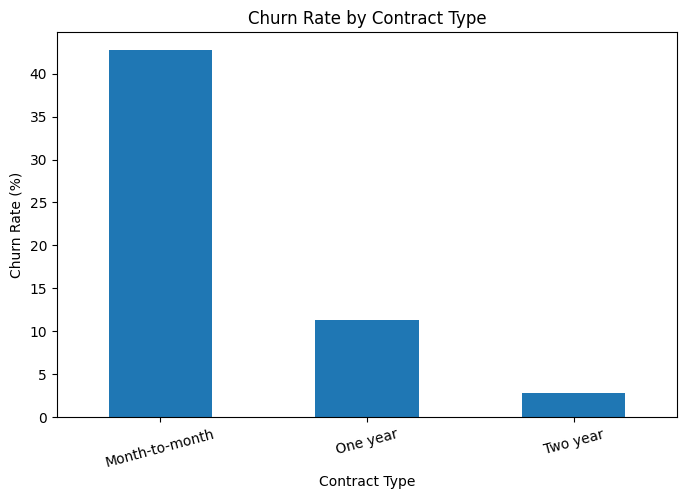

In [25]:
plt.figure(figsize=(8, 5))

contract_churn_rate.plot(kind="bar")

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=15)
plt.show()

In [29]:
#Churn by tenure group
tenure_churn = pd.crosstab(
    df["TenureGroup"],
    df["Churn"]
)

print(tenure_churn)

Churn          No   Yes
TenureGroup            
0-1 Year     1149  1037
1-2 Years     730   294
2-4 Years    1269   325
4+ Years     2026   213


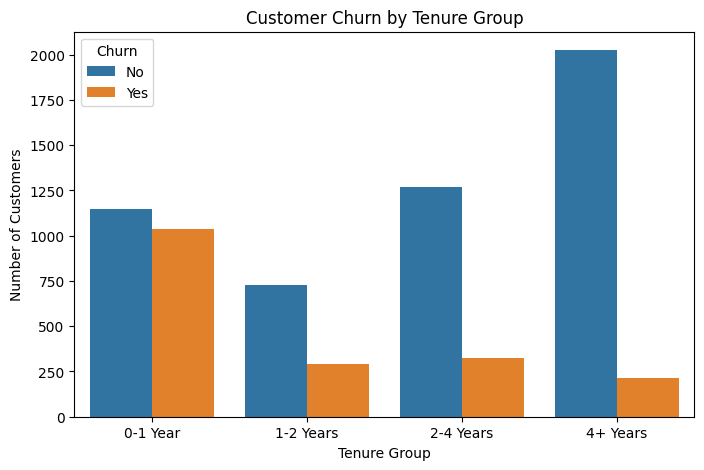

In [30]:
tenure_order = [
    "0-1 Year",
    "1-2 Years",
    "2-4 Years",
    "4+ Years"
]

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="TenureGroup",
    hue="Churn",
    order=tenure_order
)

plt.title("Customer Churn by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Number of Customers")
plt.show()

In [31]:
#Churn by payment method
payment_churn_rate = (
    df.groupby("PaymentMethod")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

print(payment_churn_rate)

PaymentMethod
Electronic check             45.285412
Mailed check                 19.106700
Bank transfer (automatic)    16.709845
Credit card (automatic)      15.243101
Name: Churn, dtype: float64


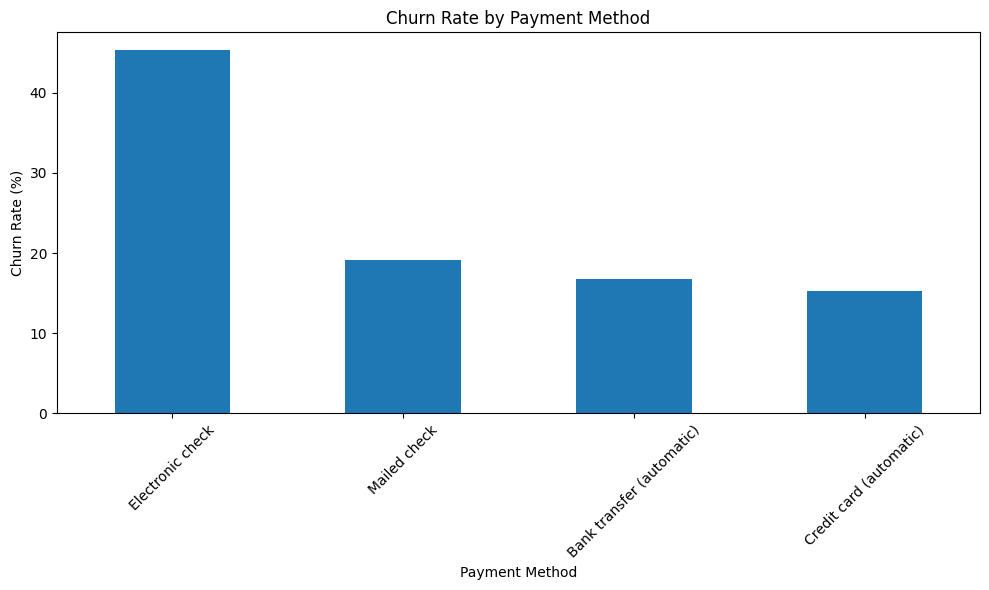

In [32]:
plt.figure(figsize=(10, 6))

payment_churn_rate.plot(kind="bar")

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

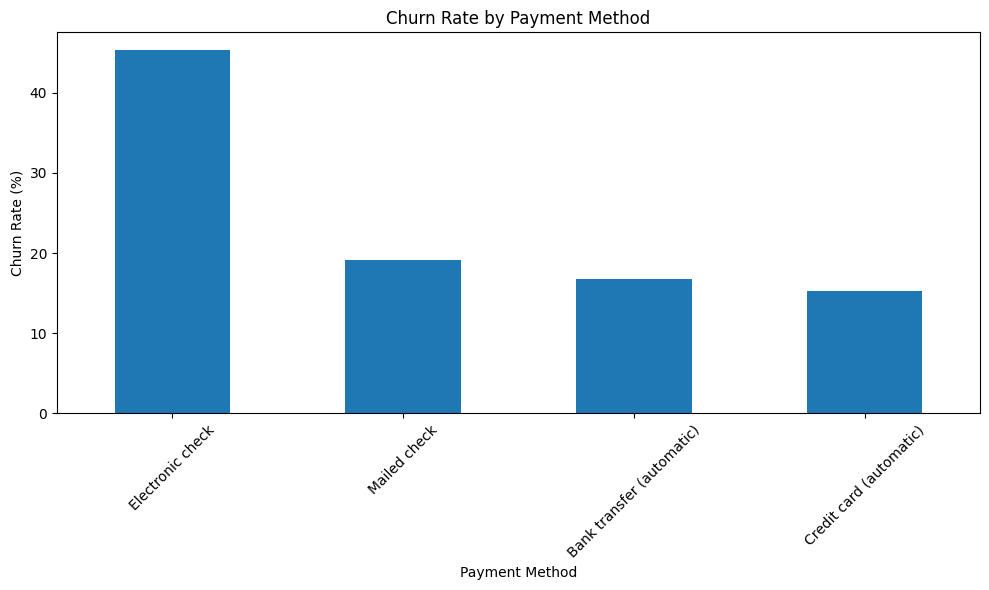

In [33]:
plt.figure(figsize=(10, 6))

payment_churn_rate.plot(kind="bar")

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [34]:
#Churn by internet service
internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"]
)

print(internet_churn)

Churn              No   Yes
InternetService            
DSL              1962   459
Fiber optic      1799  1297
No               1413   113


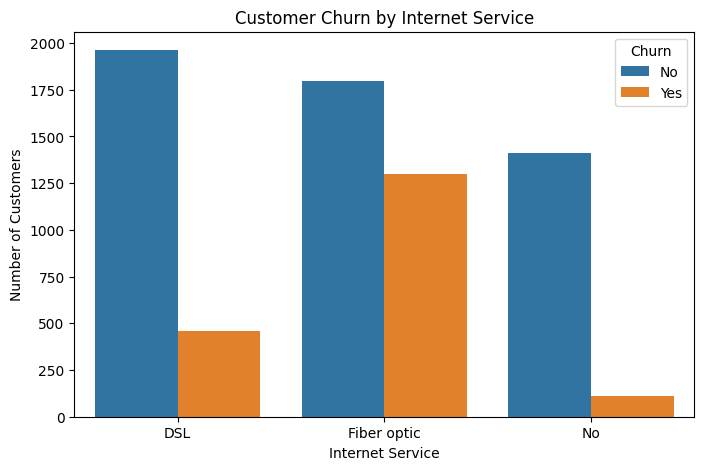

In [35]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="InternetService",
    hue="Churn"
)

plt.title("Customer Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.show()

In [36]:
#Monthly charges by churn status
monthly_charges_churn = (
    df.groupby("Churn")["MonthlyCharges"]
    .mean()
)

print(monthly_charges_churn)

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64


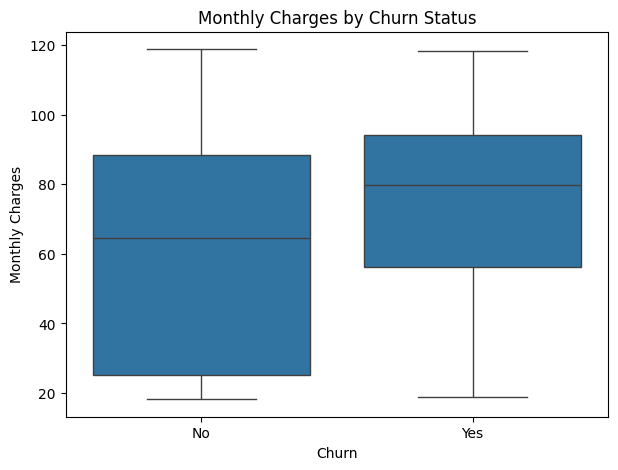

In [37]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

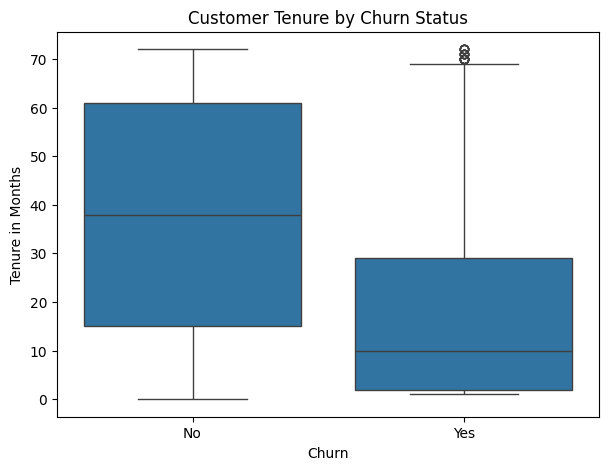

In [38]:
#Tenure by churn status
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Customer Tenure by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Tenure in Months")
plt.show()

In [39]:
#Churn by gender
gender_churn_rate = (
    df.groupby("gender")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

print(gender_churn_rate)

gender
Female    26.920872
Male      26.160338
Name: Churn, dtype: float64


In [40]:
#Churn by senior citizen status
senior_churn_rate = (
    df.groupby("SeniorCitizen")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

print(senior_churn_rate)

SeniorCitizen
No     23.606168
Yes    41.681261
Name: Churn, dtype: float64


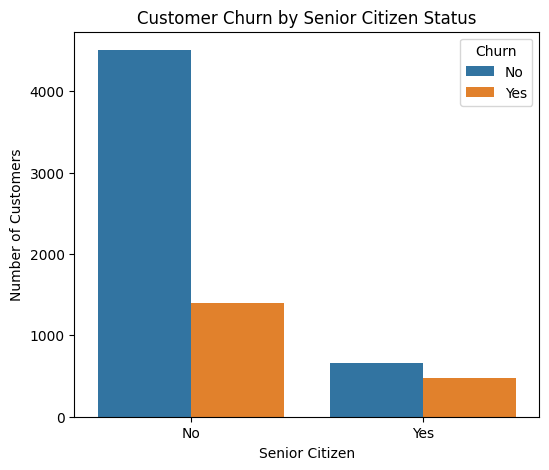

In [41]:
plt.figure(figsize=(6, 5))

sns.countplot(
    data=df,
    x="SeniorCitizen",
    hue="Churn"
)

plt.title("Customer Churn by Senior Citizen Status")
plt.xlabel("Senior Citizen")
plt.ylabel("Number of Customers")
plt.show()

In [42]:
#Churn by tech support
tech_support_churn = (
    df.groupby("TechSupport")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

print(tech_support_churn)

TechSupport
No                     41.635474
Yes                    15.166341
No internet service     7.404980
Name: Churn, dtype: float64


In [43]:
#Churn by online security
security_churn = (
    df.groupby("OnlineSecurity")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

print(security_churn)

OnlineSecurity
No                     41.766724
Yes                    14.611194
No internet service     7.404980
Name: Churn, dtype: float64


In [44]:
#Correlation Analysis
#Step 30: Create a numeric churn column
df["ChurnValue"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

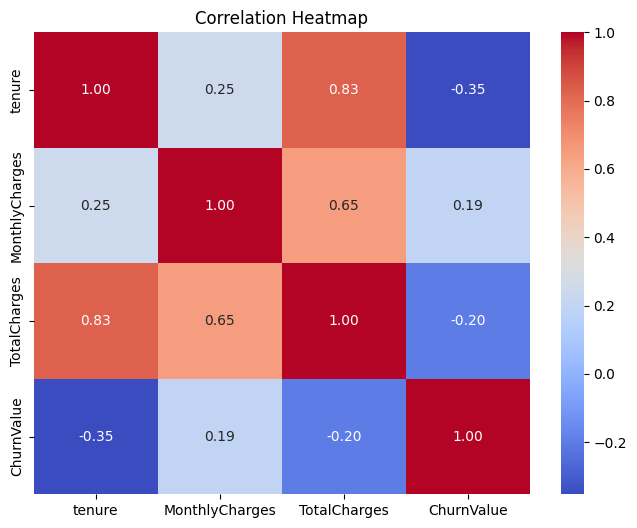

In [45]:
#Correlation heatmap
numeric_columns = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "ChurnValue"
]

correlation = df[numeric_columns].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

In [46]:
#Customer Segment Analysis
#Step 32: Identify high-value churned customers

#For this project, you can define a high-value customer as someone with above-average TotalCharges.

average_total_charges = df["TotalCharges"].mean()

high_value_churned = df[
    (df["TotalCharges"] > average_total_charges) &
    (df["Churn"] == "Yes")
]

print(
    "High-Value Churned Customers:",
    len(high_value_churned)
)

High-Value Churned Customers: 475


In [47]:
high_value_churned[
    [
        "customerID",
        "tenure",
        "Contract",
        "MonthlyCharges",
        "TotalCharges",
        "PaymentMethod"
    ]
].head(10)

,customerID,tenure,Contract,MonthlyCharges,TotalCharges,PaymentMethod
8,7892-POOKP,28,Month-to-month,104.80,3046.05,Electronic check
13,0280-XJGEX,49,Month-to-month,103.70,5036.30,Bank transfer (automatic)
26,6467-CHFZW,47,Month-to-month,99.35,4749.15,Electronic check
38,5380-WJKOV,34,Month-to-month,106.35,3549.25,Electronic check
99,4598-XLKNJ,25,Month-to-month,98.50,2514.50,Electronic check
104,3192-NQECA,68,Two year,110.00,7611.85,Bank transfer (automatic)
110,0486-HECZI,55,Month-to-month,96.75,5238.90,Electronic check
113,4846-WHAFZ,37,Month-to-month,76.50,2868.15,Electronic check
168,3445-HXXGF,58,Month-to-month,45.30,2651.20,Electronic check
173,0691-JVSYA,53,One year,94.85,5000.20,Bank transfer (automatic)


In [48]:
#Create KPI summary
kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Customers",
        "Churned Customers",
        "Retained Customers",
        "Churn Rate (%)",
        "Retention Rate (%)",
        "Average Monthly Charges"
    ],
    "Value": [
        total_customers,
        churned_customers,
        retained_customers,
        round(churn_rate, 2),
        round(retention_rate, 2),
        round(average_monthly_charges, 2)
    ]
})

kpi_summary

,KPI,Value
0,Total Customers,7043.00
1,Churned Customers,1869.00
2,Retained Customers,5174.00
3,Churn Rate (%),26.54
4,Retention Rate (%),73.46
5,Average Monthly Charges,64.76


In [49]:
df.to_csv(
    "cleaned_telco_customer_churn.csv",
    index=False
)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [50]:
from google.colab import files

files.download(
    "cleaned_telco_customer_churn.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>